In [ ]:
# Cross Validation 

In [4]:
# Scenario-Based Question
# A university wants to build a predictive model to estimate
#  student grades based on four factors:
# - Study hours per week
# - Attendance percentage
# - Previous exam score
# - Average sleep hours
# They collect data from 200 students and decide to use Ridge
#  Regression for prediction. To evaluate the model, they apply different cross-validation strategies:
# - Basic K-Fold CV (5 folds, shuffled) to check the stability of the model’s R² scores.
# - Multi-metric evaluation using both R² and Mean Squared Error (MSE), comparing training and validation
# scores.
# - Stratified K-Fold CV (for a separate classification task predicting pass/fail using Logistic
#                         Regression).


from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
import numpy as np

# Step 1: Create synthetic dataset
# 1000 samples, 5 features
X, y = make_regression(
    n_samples=1000,
    n_features=5,
    noise=15,
    random_state=42
)

# Step 2: Initialize model
model = LinearRegression()

# Step 3: Define K-Fold
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Step 4: Perform cross-validation
scores = cross_val_score(
    model,
    X,
    y,
    cv=kfold,
    scoring='r2'
)

# Step 5: Print results
print("R2 scores for each fold:", scores)
print("Average R2 score:", np.mean(scores))

if scores.std()<0.05:
    print("model is stable")

else:
    print("model performance varies across folds so require investigation")

R2 scores for each fold: [0.93737232 0.94451228 0.9453228  0.94662937 0.94710768]
Average R2 score: 0.9441888878564523
model is stable


In [10]:
# Scenario: Predicting Patient Recovery Time
# A hospital research team wants to build a model to predict patient recovery time (in days) after
#  surgery based on several factors such as:
# - Age of the patient
# - Number of hours of post-surgery physiotherapy per week
# - Pre-existing health conditions (numeric severity score)
# - Length of hospital stay (days)
# - Average sleep hours during recovery
# They collect data from 1,000 patients and decide to use Linear Regression.
# To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.



# Predicting Patient Recovery Time
# Linear Regression + 5-Fold CV (R²)


import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression


# Step 1: Create Synthetic Dataset

# 1000 patients, 5 features

X, y = make_regression(n_samples=1000,
                       n_features=5,
                       noise=15,
                       random_state=42)

# Step 2: Define Linear Regression Model

model = LinearRegression()

# Step 3: Define 5-Fold Cross Validation


kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Step 4: Evaluate using R²

r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

print("R² scores for each fold:", r2_scores.round(3))
print("Mean R²:", r2_scores.mean().round(3))
print("Standard Deviation:", r2_scores.std().round(3))

# Step 5: Interpretation

if r2_scores.std() < 0.05:
    print("\nModel performance is stable across folds.")
else:
    print("\nModel performance varies across folds.")

R² scores for each fold: [0.937 0.945 0.945 0.947 0.947]
Mean R²: 0.944
Standard Deviation: 0.004

Model performance is stable across folds.


In [11]:
# Scenario: Predicting Student Exam Performance
# A university research team wants to build a model to predict student exam scores (out of 100) based on several factors such as:
# - Number of study hours per week
# - Attendance percentage in lectures
# - Prior GPA (Grade Point Average)
# - Participation in group projects (numeric engagement score)
# - Average sleep hours during exam preparation
# They collect data from 800 students across different departments and decide to use Linear Regression.
# To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

# step 1 : Create synthetic dataset

# 800 students , 5 features

X, y = make_regression(n_samples= 800,
                      n_features = 5,
                      noise = 15,
                      random_state = 42)

# step 2 : Define Linear Regression Model

model = LinearRegression()

# step 3: Define 5-Fold Cross Validation

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Step 4: Evaluate using R²

r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

print("R² scores for each fold:", r2_scores.round(3))
print("Mean R²:", r2_scores.mean().round(3))
print("Standard Deviation:", r2_scores.std().round(3))

# Step 5: Interpretation

if r2_scores.std() < 0.05:
    print("Model performance is stable across folds.")
else:
    print("Model performance varies across folds.")

R² scores for each fold: [0.987 0.988 0.989 0.988 0.988]
Mean R²: 0.988
Standard Deviation: 0.001
Model performance is stable across folds.


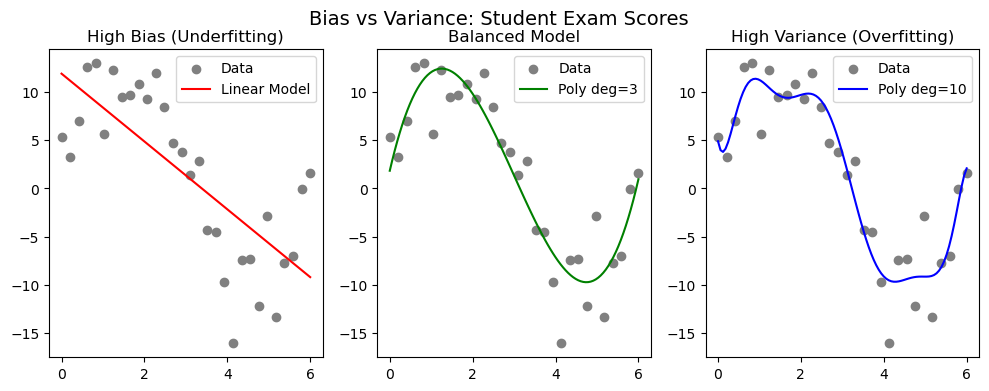

In [12]:
# Scenario: Predicting Student Exam Scores
# A school wants to build a model to predict student exam scores based on study hours. They collect data
# from 30 students, but the scores are noisy because of other factors (like sleep, stress, or health).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes scores increase perfectly with study hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts too low or too high compared to actual scores,
# what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different 
# predictions when tested on new students, what does this show about variance?
# - Part C: Which model is likely to generalize better to new students, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance” to
#  a teacher who doesn’t know machine learning?

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# --- Step 1: Simulate dataset ---
# 30 students, study hours vs exam scores (with noise)
np.random.seed(0)
X = np.linspace(0, 6, 30).reshape(-1, 1)   # study hours
y = (10 * np.sin(X)).ravel() + np.random.normal(scale=3, size=30)  # exam scores with noise

# --- Step 2: Define models ---
linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression())   # simple line
poly_model   = make_pipeline(PolynomialFeatures(10), LinearRegression())  # complex curve
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression()) # "just right"

# --- Step 3: Fit models ---
linear_model.fit(X, y)
poly_model.fit(X, y)
balanced_model.fit(X, y)

# --- Step 4: Predictions ---
X_test = np.linspace(0, 6, 100).reshape(-1, 1)
y_linear   = linear_model.predict(X_test)
y_poly     = poly_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)

# --- Step 5: Plot results ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.legend()

plt.suptitle("Bias vs Variance: Student Exam Scores", fontsize=14)
plt.show()

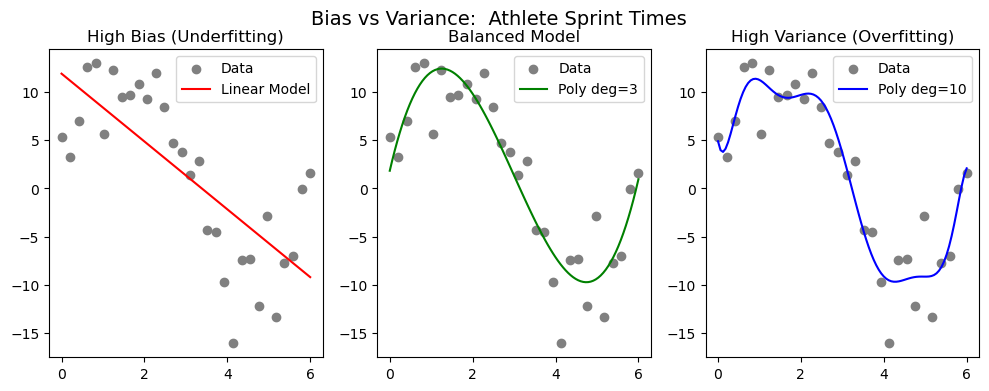

In [13]:
# Scenario: Predicting Athlete Performance
# A sports academy wants to build a model to predict athlete sprint times (in seconds) based on training
#  hours. They collect data from 30 athletes, but the sprint times are noisy because of other factors (like diet, fatigue, or weather).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes sprint times improve perfectly with more
#  training hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts sprint times that are too fast or too slow compared
#  to actual results, what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different
# predictions when tested on new athletes, what does this show about variance?
# - Part C: Which model is likely to generalize better to new athletes, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance”
#  to a coach who doesn’t know machine learning?


import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# --- Step 1: Simulate dataset ---
# 30 students, training hours vs athlete sprint times (with noise)
np.random.seed(0)
X = np.linspace(0, 6, 30).reshape(-1, 1)   # study hours
y = (10 * np.sin(X)).ravel() + np.random.normal(scale=3, size=30)  #  athlete sprint times (with noise)

# --- Step 2: Define models ---
linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression())   # simple line
poly_model   = make_pipeline(PolynomialFeatures(10), LinearRegression())  # complex curve
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression()) # "just right"

# --- Step 3: Fit models ---
linear_model.fit(X, y)
poly_model.fit(X, y)
balanced_model.fit(X, y)

# --- Step 4: Predictions ---
X_test = np.linspace(0, 6, 100).reshape(-1, 1)
y_linear   = linear_model.predict(X_test)
y_poly     = poly_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)

# --- Step 5: Plot results ---
plt.figure(figsize=(12, 4))


plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.legend()

plt.suptitle("Bias vs Variance:  Athlete Sprint Times", fontsize=14)
plt.show()

In [19]:
# Label Encoding


# Scenario: Package Delivery System
# A logistics company wants to build a machine learning model to optimize package delivery.
# They collect data about each package, including:
# - Size: Small, Medium, Large
# - Priority: Low, Medium, High
# Since machine learning models work with numbers (not text labels), the company decides to use Label
#  Encoding to convert these categories into numeric values.
# They apply Scikit-learn’s LabelEncoder to both features:
# - Size → converted into numeric codes (e.g., Small = 2, Medium = 1, Large = 0)
# - Priority → converted into numeric codes (e.g., Low = 1, Medium = 2, High = 0)
# They also check the mapping and decode the numbers back to the original labels to ensure correctness.

# Questions for Learners
# Part A: Why does the company need to convert categorical values like Small, Medium, Large into numbers 
# before training a model?
# Part B: If the encoded values are 0, 1, 2, does the order (e.g., Large = 0, Medium = 1, Small = 2) 
# matter for all models? Why or why not?
# Part C: How can the company decode the numeric values back into the original labels after prediction?
# Part D (Applied): Suppose the company adds a new category “Extra Large.” How would LabelEncoder handle 
# this, and what challenge might arise if the model was already trained?


import pandas as pd
from sklearn.preprocessing import LabelEncoder


# Step 1: Sample data

data = pd.DataFrame({
    'Size': ['Small', 'Medium', 'Large', 'Medium', 'Small'],
    'Priority': ['Low', 'High', 'Medium', 'Low', 'High']
})

# step 2: Apply Label Encoding

le_size = LabelEncoder()
data['Size_Encoded'] = le_size.fit_transform(data['Size'])

le_priority = LabelEncoder()
data['Priority_Encoded'] = le_priority.fit_transform(data['Priority'])

# step 3: View the encoding mapping
print("Size mapping:", dict(zip(le_size.classes_,
                               le_size.transform(le_size.classes_))))

print("Priority mapping:", dict(zip(le_priority.classes_,
                                   le_priority.transform(le_priority.classes_))))

# step 4: Inverse transform (decode back to original labels)
decoded_size = le_size.inverse_transform([0,1,2])
print("Decoded Size:", decoded_size)

# step 5: Final encoded dataset

print("\nEncoded DataFrame:")
print(data)


Size mapping: {'Large': np.int64(0), 'Medium': np.int64(1), 'Small': np.int64(2)}
Priority mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Decoded Size: ['Large' 'Medium' 'Small']

Encoded DataFrame:
     Size Priority  Size_Encoded  Priority_Encoded
0   Small      Low             2                 1
1  Medium     High             1                 0
2   Large   Medium             0                 2
3  Medium      Low             1                 1
4   Small     High             2                 0


In [22]:
# Scenario: Restaurant Ordering System
# A restaurant wants to build a machine learning model to predict order preparation time.
# They collect data about each order, including:
# - Meal Type: Breakfast, Lunch, Dinner
# - Spice Level: Mild, Medium, Hot
# Since models can’t directly work with text labels, the restaurant uses Label Encoding to 
# convert these categories into numbers.


import pandas as pd
from sklearn.preprocessing import LabelEncoder

data = pd.DataFrame({
    'Meal_Type': ['Breakfast', 'Lunch', 'Dinner', 'Lunch', 'Breakfast'],
    'Spice_Level': ['Mild', 'Hot', 'Medium', 'Mild', 'Hot']
})

le_meal = LabelEncoder()
data['Meal_Encoded'] = le_meal.fit_transform(data['Meal_Type'])

le_spice = LabelEncoder()
data['Spice_Encoded'] = le_spice.fit_transform(data['Spice_Level'])

print("Meal Mapping:", dict(zip(le_meal.classes_,
                                le_meal.transform(le_meal.classes_))))

print("Spice Mapping:", dict(zip(le_spice.classes_,
                                 le_spice.transform(le_spice.classes_))))

decoded_size = le_size.inverse_transform([0,1,2])
print("Decoded Size:", decoded_size)

print("\nEncoded DataFrame:")
print(data)

Meal Mapping: {'Breakfast': np.int64(0), 'Dinner': np.int64(1), 'Lunch': np.int64(2)}
Spice Mapping: {'Hot': np.int64(0), 'Medium': np.int64(1), 'Mild': np.int64(2)}
Decoded Size: ['Large' 'Medium' 'Small']

Encoded DataFrame:
   Meal_Type Spice_Level  Meal_Encoded  Spice_Encoded
0  Breakfast        Mild             0              2
1      Lunch         Hot             2              0
2     Dinner      Medium             1              1
3      Lunch        Mild             2              2
4  Breakfast         Hot             0              0


In [23]:
# Scenario: Employee Training & Satisfaction Survey
# A company conducts a survey to understand how employee education level and job satisfaction affect performance.
# They collect data such as:
# - Education: High School, Bachelor, Master, PhD
# - Satisfaction: Poor, Average, Good, Excellent
# Since these categories have a natural order (e.g., PhD is higher than Bachelor, Excellent is better
#  than Good), the company decides to use Ordinal Encoding to convert them into numbers that respect 
#  this ranking.
# They define custom ordering:
# - Education → High School (0), Bachelor (1), Master (2), PhD (3)
# - Satisfaction → Poor (0), Average (1), Good (2), Excellent (3)
# They also compare this with a manual dictionary mapping to ensure consistency.

# Questions for Learners
# Part A: Why is it important to use Ordinal Encoding instead of simple Label Encoding for ordered 
# categories like education level?
# Part B: If the company encoded “PhD = 0” and “High School = 3,” what problem might arise in 
# interpreting the model?
# Part C: How does Ordinal Encoding differ from One-Hot Encoding in representing categorical data?
# Part D (Applied): Suppose the company adds a new satisfaction level “Outstanding.” How should they 
# update their encoding scheme to keep the order meaningful?


import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# Step 1: Sample data
data = pd.DataFrame({
    'Education': ['High School', 'Bachelor', 'Master', 'PhD'],
    'Satisfaction': ['Poor', 'Average', 'Good', 'Excellent']
})

print("Original Data:\n", data)

# Step 2: Define custom order
categories = [
    ['High School', 'Bachelor', 'Master', 'PhD'],
    ['Poor', 'Average', 'Good', 'Excellent']
]

# Step 3: Create encoder
encoder = OrdinalEncoder(categories=categories)

# Step 4: Apply encoding
data[['Education_Encoded', 'Satisfaction_Encoded']] = encoder.fit_transform(data)

print("\nAfter Ordinal Encoding:\n", data)

# Manual mapping dictionaries
education_map = {
    'High School': 0,
    'Bachelor': 1,
    'Master': 2,
    'PhD': 3
}

satisfaction_map = {
    'Poor': 0,
    'Average': 1,
    'Good': 2,
    'Excellent': 3
}

# Apply manual mapping
data['Education_Manual'] = data['Education'].map(education_map)
data['Satisfaction_Manual'] = data['Satisfaction'].map(satisfaction_map)

print("\nManual Mapping:\n", data)



Original Data:
      Education Satisfaction
0  High School         Poor
1     Bachelor      Average
2       Master         Good
3          PhD    Excellent

After Ordinal Encoding:
      Education Satisfaction  Education_Encoded  Satisfaction_Encoded
0  High School         Poor                0.0                   0.0
1     Bachelor      Average                1.0                   1.0
2       Master         Good                2.0                   2.0
3          PhD    Excellent                3.0                   3.0

Manual Mapping:
      Education Satisfaction  Education_Encoded  Satisfaction_Encoded  \
0  High School         Poor                0.0                   0.0   
1     Bachelor      Average                1.0                   1.0   
2       Master         Good                2.0                   2.0   
3          PhD    Excellent                3.0                   3.0   

   Education_Manual  Satisfaction_Manual  
0                 0                    0  
1       

In [24]:
# Scenario: Patient Health Monitoring
# A hospital wants to analyze patient records to understand how disease severity and recovery 
# satisfaction affect treatment outcomes.
# They collect data such as:
# - Disease Severity: Mild, Moderate, Severe, Critical
# - Recovery Satisfaction: Poor, Average, Good, Excellent
# Since these categories have a natural order (e.g., Critical is worse than Mild, Excellent is 
# better than Poor), the hospital uses Ordinal Encoding to convert them into numbers that respect this
#  ranking.
# They define custom ordering:
# - Disease Severity → Mild (0), Moderate (1), Severe (2), Critical (3)
# - Recovery Satisfaction → Poor (0), Average (1), Good (2), Excellent (3)
# They also compare this with a manual dictionary mapping to ensure consistency.

import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# Step 1: Sample Data
data = pd.DataFrame({
    'Disease_Severity': ['Mild', 'Moderate', 'Severe', 'Critical'],
    'Recovery_Satisfaction': ['Poor', 'Average', 'Good', 'Excellent']
})

print("Original Data:\n", data)

# Step 2: Define Custom Order
categories = [
    ['Mild', 'Moderate', 'Severe', 'Critical'],
    ['Poor', 'Average', 'Good', 'Excellent']
]

# Step 3: Create Ordinal Encoder
encoder = OrdinalEncoder(categories=categories)

# Step 4: Apply Encoding
data[['Severity_Encoded', 'Satisfaction_Encoded']] = encoder.fit_transform(data)

print("\nAfter Ordinal Encoding:\n", data)

# Manual mapping dictionaries
severity_map = {
    'Mild': 0,
    'Moderate': 1,
    'Severe': 2,
    'Critical': 3
}

satisfaction_map = {
    'Poor': 0,
    'Average': 1,
    'Good': 2,
    'Excellent': 3
}

# Apply manual mapping
data['Severity_Manual'] = data['Disease_Severity'].map(severity_map)
data['Satisfaction_Manual'] = data['Recovery_Satisfaction'].map(satisfaction_map)

print("\nManual Mapping Comparison:\n", data)

Original Data:
   Disease_Severity Recovery_Satisfaction
0             Mild                  Poor
1         Moderate               Average
2           Severe                  Good
3         Critical             Excellent

After Ordinal Encoding:
   Disease_Severity Recovery_Satisfaction  Severity_Encoded  \
0             Mild                  Poor               0.0   
1         Moderate               Average               1.0   
2           Severe                  Good               2.0   
3         Critical             Excellent               3.0   

   Satisfaction_Encoded  
0                   0.0  
1                   1.0  
2                   2.0  
3                   3.0  

Manual Mapping Comparison:
   Disease_Severity Recovery_Satisfaction  Severity_Encoded  \
0             Mild                  Poor               0.0   
1         Moderate               Average               1.0   
2           Severe                  Good               2.0   
3         Critical             Exce

In [26]:
#OneHotEncoder


# Scenario: Online Food Delivery App
# An online food delivery company wants to build a machine learning model to predict delivery time based
#  on the type of cuisine ordered.
# They collect data such as:
# - Cuisine Type: Italian, Chinese, Indian, Mexican
# Since machine learning models can’t directly work with text labels, the company decides to use One-Hot
#  Encoding.
# This method creates a new column for each cuisine type:
# - Italian → [1, 0, 0, 0]
# - Chinese → [0, 1, 0, 0]
# - Indian → [0, 0, 1, 0]
# - Mexican → [0, 0, 0, 1]
# They set sparse=False so the encoder returns a regular NumPy array instead of a sparse matrix, making
#  the results easier to read and print for analysis.

# Questions for Learners
# Part A: Why is One-Hot Encoding more appropriate than Label Encoding for categories like cuisine type?
# Part B: What does sparse=False do, and why might it be useful in this scenario?
# Part C: If the company adds a new cuisine type (e.g., “Thai”), how will One-Hot Encoding handle it?
# Part D (Applied): What potential problem could arise if the company has hundreds of cuisine types, and
#  how might they solve it?


import pandas as pd
from sklearn.preprocessing import OneHotEncoder

orders = pd.DataFrame({
    'Cuisine': ['Italian','Chinese','Indian','Mexican','Chinese','Italian']
})

# step 2 : Apply OneHotEncoder

encoder = OneHotEncoder(sparse_output = False)
encoded_array = encoder.fit_transform(orders[['Cuisine']])

# step 3: Convert encoded array back into a DataFrame for readability
encoded_df = pd.DataFrame(encoded_array, columns= encoder.categories_[0])

# step 4: Combine with original data
final_data = pd.concat([orders, encoded_df], axis=1)

# step 5: Display Results

print("Cuisine Categories:", encoder.categories_)
print("\Encoded Array:\n", encoded_array)
print("\nFinal Encoded DataFrame:")
print(final_data)

Cuisine Categories: [array(['Chinese', 'Indian', 'Italian', 'Mexican'], dtype=object)]
\Encoded Array:
 [[0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]]

Final Encoded DataFrame:
   Cuisine  Chinese  Indian  Italian  Mexican
0  Italian      0.0     0.0      1.0      0.0
1  Chinese      1.0     0.0      0.0      0.0
2   Indian      0.0     1.0      0.0      0.0
3  Mexican      0.0     0.0      0.0      1.0
4  Chinese      1.0     0.0      0.0      0.0
5  Italian      0.0     0.0      1.0      0.0
